# SensorThings API Air Quality Sensor Data Exploration

### 📘 Notebook Overview
* Explore data from any OGC SensorThings API server
* Connect, download observations, map location, plot time‑series
* Export CSV & Excel
* Visual analysis & anomaly detection

This notebook allows you to interactively explore air and environmental data from **SensorThings API** compatible air quality devices.

> Supports standard SensorThings servers, including [NILU VirtualAir](https://api-virtualair.nilu.no/v1.1) and [CitiObs Demo](https://citiobs.demo.secure-dimensions.de/staplus/v1.1)

#### Before starting run the next cell to install the required Python libraries first required to run the code:

In [ ]:
# Run once
!pip install staplus-client requests pandas plotly matplotlib seaborn scipy statsmodels calplot openpyxl shapely
!pip install --upgrade pip

### 📡 Step 1 – Retrieve sensor data from a STA/STAplus server

This step allows you to interactively retrieve environmental sensor data from a SensorThings API server to list the Datastreams and retrieve observations.

▶️ Run the next cell and follow the prompts to:

1. **Enter a valid STA/STAplus url** (e.g., https://api-virtualair.nilu.no/v1.1)
2. **Select the time range** for the data you want to retrieve (from the past 1 hour to 30 days)
3. **Choose the observed property**, such as temperature, humidity, air quality, noise, or CO₂

Once completed, this cell will:
- Retrieb the sensor observations from a Thing (sensing device).
- Display the device location on a map.
- Show a time series plot of the selected property.
- Export the data to both CSV and Excel formats with download links.
- Show the average value over the selected time range.


SensorThings endpoint (blank for demo):  https://api-virtualair.nilu.no/v1.1
Thing ID:  KTUY_10305



Time ranges:
1 – last 1 h
2 – last 8 h
3 – last 1 days
4 – last 7 days
5 – last 15 days
6 – last 30 days


Choose 1-6:  5



Datastreams:
0 – SCL_ApriSensor-7F7E-sps30-12-pm25 (id=KTUY_49993)
1 – SCL_ApriSensor-7F7E-sps30-12-pm25_kal (id=KTUY_49994)


Datastream number:  0



📍 Coordinates found (via REST): lat=52.037, lon=5.677


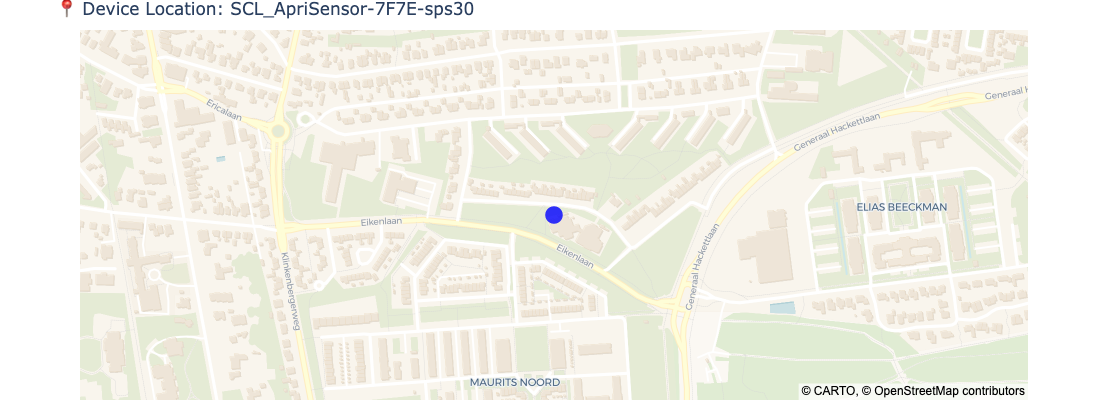

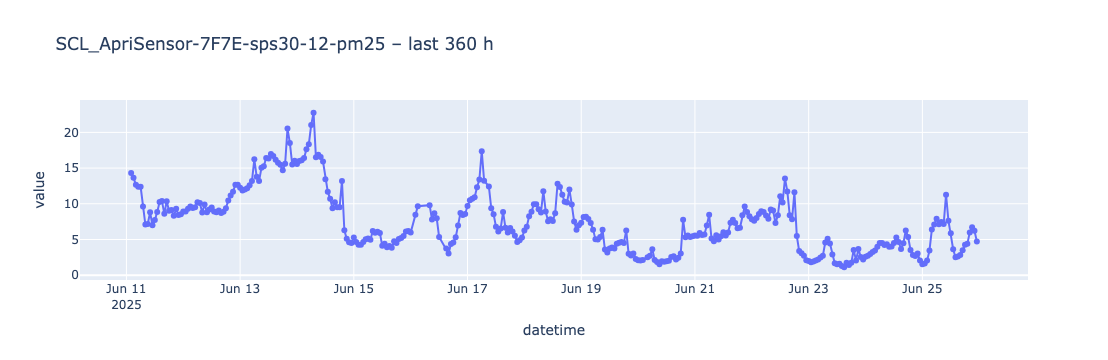

In [1]:
import os, datetime, requests
import pandas as pd, plotly.express as px
from IPython.display import display, HTML
import staplus_client as staplus
from shapely.geometry import shape

def get_sensor_data():
    try:
        endpoint = input("\nSensorThings endpoint (blank for demo): ").strip() \
                  or "https://api-virtualair.nilu.no/v1.1"
        thing_id = input("Thing ID: ").strip()
        if not thing_id:
            raise ValueError("Thing ID cannot be empty")

        # --- Time selection menu ---
        time_opts = {"1":1,"2":8,"3":24,"4":24*7,"5":24*15,"6":24*30}
        print("\nTime ranges:")
        for k, hrs in time_opts.items():
            label = f"{hrs} h" if hrs < 24 else f"{hrs//24} days"
            print(f"{k} – last {label}")
        hours_back = time_opts.get(input("Choose 1-6: ").strip())
        if not hours_back:
            raise ValueError("Invalid choice")

        # --- Connect to STAplus ---
        svc = staplus.STAplusService(endpoint)
        thing_key = thing_id if not thing_id.isdigit() else int(thing_id)
        thing = svc.things().find(thing_key)

        # --- List datastreams ---
        ds_list = sorted(thing.get_datastreams().query().list(),
                         key=lambda ds: str(ds.id))
        if not ds_list:
            raise ValueError("No Datastreams found for this Thing")

        print("\nDatastreams:")
        for idx, ds in enumerate(ds_list):
            print(f"{idx} – {ds.name} (id={ds.id})")
        ds = ds_list[int(input("Datastream number: ").strip())]

        # --- Time window ---
        now = datetime.datetime.now(datetime.timezone.utc)
        from_time = now - datetime.timedelta(hours=hours_back)

        # --- Observations via REST ---
        ds_key  = f"'{ds.id}'" if isinstance(ds.id, str) else ds.id
        obs_url = f"{endpoint.rstrip('/')}/Datastreams({ds_key})/Observations"
        obs_all = []
        while obs_url:
            page = requests.get(obs_url)
            if not page.ok:
                raise Exception(f"Failed to fetch observations: {page.status_code}")
            data = page.json()
            obs_all += data.get("value", [])
            obs_url  = data.get("@iot.nextLink")

        def parse_obs_time(o):
            t = o.get("resultTime") or o.get("phenomenonTime")
            if t is None:
                return None
            if "/" in t:
                t = t.split("/")[0]
            return pd.to_datetime(t, utc=True)

        obs = [
            (t, o["result"])
            for o in obs_all
            if (t := parse_obs_time(o)) and from_time <= t <= now
        ]
        if not obs:
            raise ValueError("No observations found in the selected window")

        df = pd.DataFrame(obs, columns=["datetime", "value"]).sort_values("datetime")

        prop = ds.observed_property.name if ds.observed_property else ds.name
        avg  = df["value"].mean()

        # --- Location (manual REST fallback) ---
        lat = lon = None
        try:
            loc_url = f"{endpoint.rstrip('/')}/Things({thing_key})/Locations?$top=1"
            resp = requests.get(loc_url)
            if resp.ok:
                loc_data = resp.json().get("value", [])
                if loc_data:
                    geom = shape(loc_data[0]["location"])
                    if geom.geom_type == "Point":
                        lon, lat = geom.coords[0]
                        print(f"\n📍 Coordinates found (via REST): lat={lat}, lon={lon}")
                    else:
                        print(f"⚠️ Unsupported geometry: {geom.geom_type}")
                else:
                    print("📭 No location found for this Thing.")
            else:
                print(f"⚠️ REST location fetch failed: {resp.status_code}")
        except Exception as ex:
            print("⚠️ Error parsing location:", ex)


        # --- Map ---
        if lat is not None and lon is not None:
            map_df = pd.DataFrame({
                "Latitude": [lat],
                "Longitude": [lon],
                "Device": [thing.name],
                "Observed Property": [prop],
                "Avg Value": [f"{avg:.2f}"]
            })
            fig_map = px.scatter_map(
                map_df, lat="Latitude", lon="Longitude",
                hover_name="Device",
                hover_data={"Observed Property": True, "Avg Value": True},
                zoom=15, height=400
            )
            fig_map.update_traces(marker=dict(size=18, color="blue", opacity=0.8))
            fig_map.update_layout(
                mapbox_style="open-street-map",
                title=f"📍 Device Location: {thing.name}",
                margin={"t": 30, "b": 0}
            )
            fig_map.show()
        else:
            print("📭 No location data available.")
            
        # --- Export ---
        os.makedirs("exports", exist_ok=True)
        safe = prop.replace(" ", "_").replace("/", "-").replace(".", "")
        base = f"exports/{safe}_DS{ds.id}_{from_time:%Y-%m-%d}_to_{now:%Y-%m-%d}"

        df["datetime"] = df["datetime"].dt.tz_convert(None)
        df.to_csv(base + ".csv", index=False)
        df.to_excel(base + ".xlsx", index=False)
        print("\n")
        display(HTML(
            f'<p><strong>Downloads:</strong> '
            f'<a href="{base}.csv" download>CSV</a> | '
            f'<a href="{base}.xlsx" download>Excel</a></p>'
            f'<p>Observations: <strong>{len(df)}</strong></p>'
        ))

        px.line(df, x="datetime", y="value",
                title=f"{prop} – last {hours_back} h", markers=True).show()

        display(HTML(f"<h3>Average {prop}: <strong>{avg:.2f}</strong></h3><hr>"))

        return df, prop, avg, f"{hours_back}h"

    except Exception as e:
        print("Error:", e)
        return None, None, None, None

# ▶️ Run it
readings_df, observed_property_name, observations_avg, time_interval_str = get_sensor_data()

### 🔍 Step 2: Explore the Sensor Data with Visualizations

This step provides multiple plots to help you better understand the trends, patterns, and outliers in your selected sensor observations.

Depending on the selected time range, the outputs may include:

- 📊 **Histogram**: Distribution of all measurement values.
- 📈 **Rolling Average Plot**: Smoothed time series to highlight trends.
- ⏰ **Hourly Average Plot**: Average value by hour of the day (if enough hourly diversity).
- 📦 **Box Plot**: Summary of value distribution with quartiles and outliers.
- 📅 **Daily Average Time Series**: For time ranges of 7 days or more.
- 🗓️ **Calendar Heatmap**: Visualizes daily average values like a GitHub contributions chart.
- 📉 **Weekday vs Weekend Comparison**: Box plots showing differences between weekdays and weekends.
- 🚨 **Anomaly Detection**:
  - If the data is normally distributed: uses **z-score**.
  - Otherwise: uses the **IQR method** and shows a **Q-Q plot** for visual inspection.

These visual tools are meant to support data interpretation, helping users spot unusual values or daily/weekly patterns.

▶️ Run the next cell.

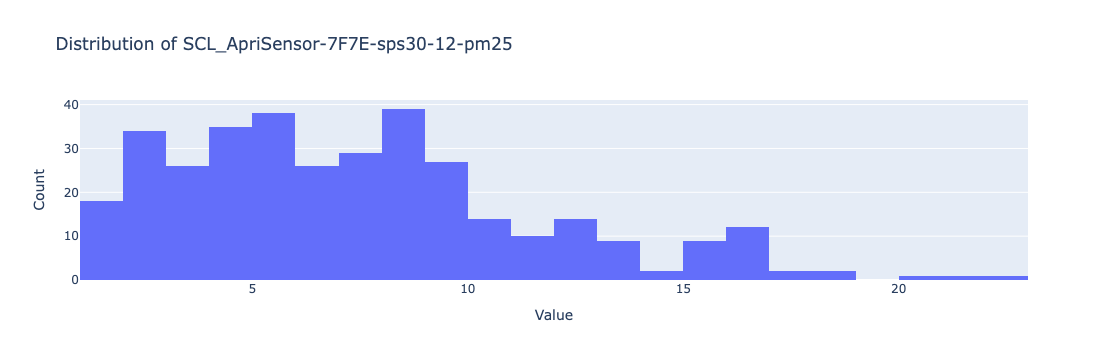

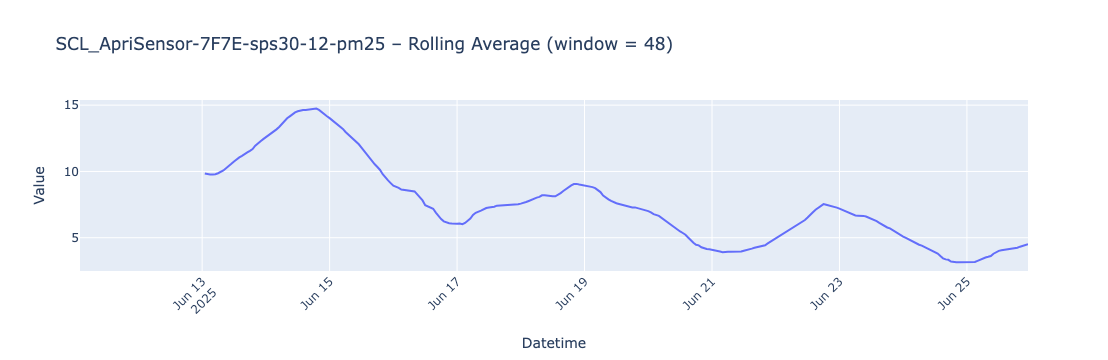

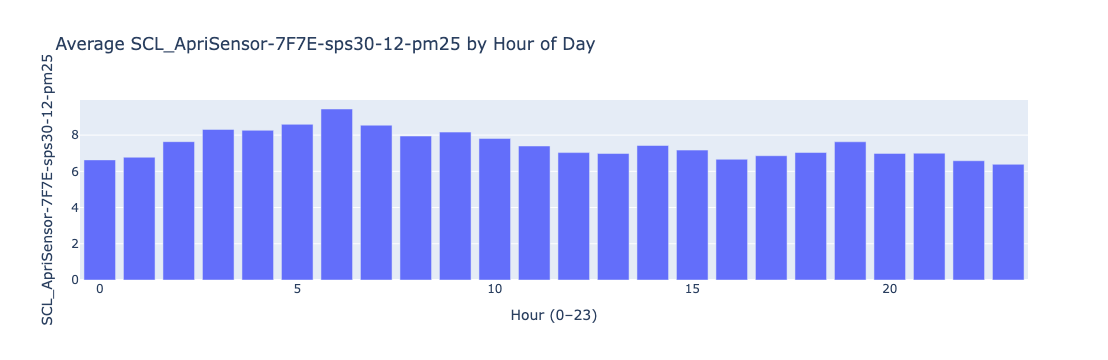

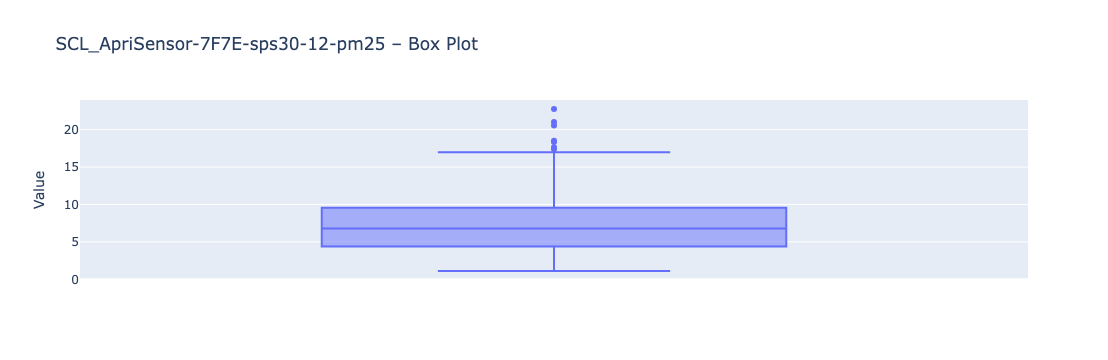

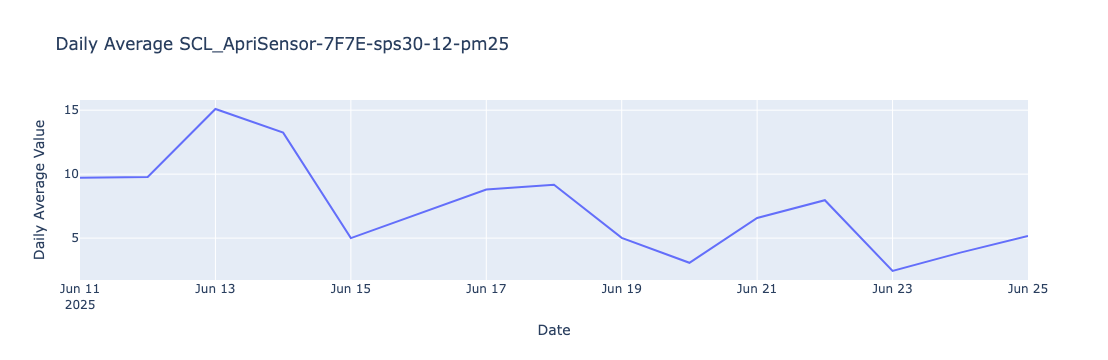

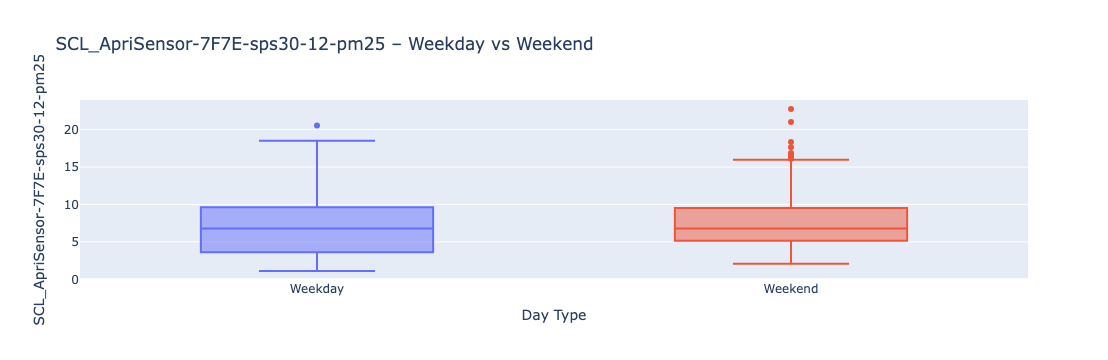

📊 Normality test used: Shapiro-Wilk | p-value = 0.0000


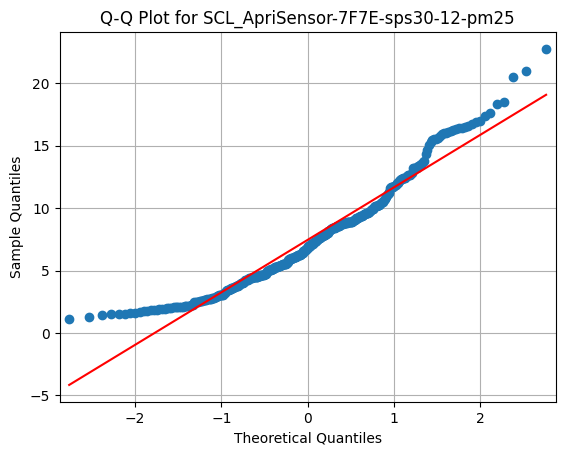

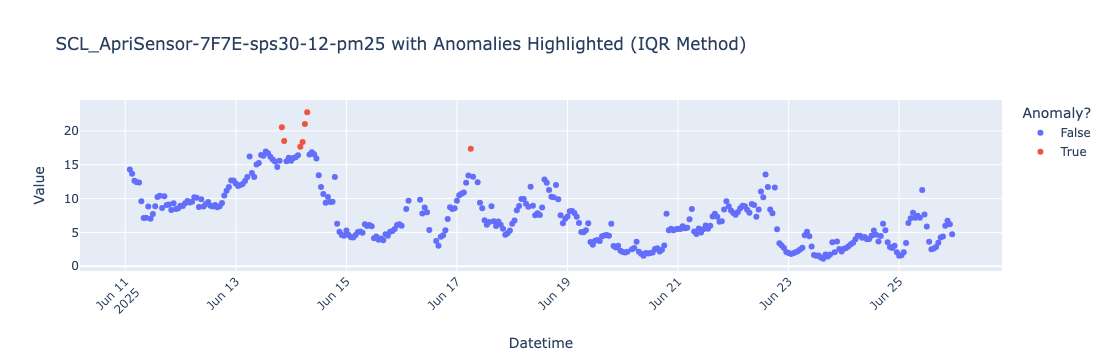

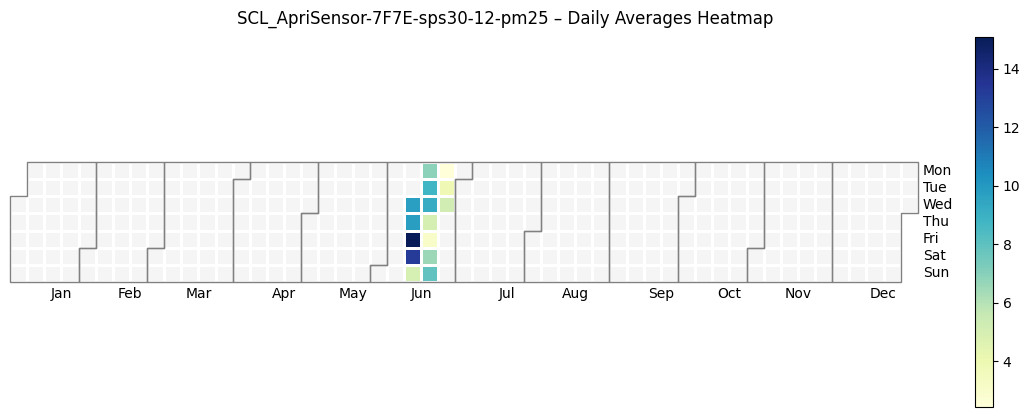

In [2]:
import numpy as np
from scipy.stats import shapiro, normaltest
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Optional: handle calplot gracefully if not installed
try:
    import calplot
except ImportError:
    calplot = None
    print("⚠️ calplot not installed. Calendar heatmap will be skipped.")

if readings_df is not None:
    time_range_hours = int(time_interval_str.replace("h", ""))

    # 1. Histogram
    px.histogram(
        readings_df, x="value", nbins=30,
        title=f"Distribution of {observed_property_name}",
        labels={"value": observed_property_name}
    ).update_xaxes(title_text="Value").update_yaxes(title_text="Count").show()

    # 2. Rolling average
    rolling_window = (
        3 if time_range_hours <= 1 else
        5 if time_range_hours <= 8 else
        10 if time_range_hours <= 24 else
        24 if time_range_hours <= 24 * 7 else
        48 if time_range_hours <= 24 * 15 else
        72
    )
    readings_df["rolling_avg"] = readings_df["value"].rolling(window=rolling_window).mean()

    px.line(
        readings_df, x="datetime", y="rolling_avg",
        title=f"{observed_property_name} – Rolling Average (window = {rolling_window})",
        labels={"rolling_avg": f"Smoothed {observed_property_name}"}
    ).update_xaxes(title_text="Datetime", tickangle=-45).update_yaxes(title_text="Value").show()

    # 3. Hourly pattern
    if readings_df["datetime"].dt.hour.nunique() > 2:
        hourly_avg = readings_df.assign(hour=readings_df["datetime"].dt.hour) \
                                .groupby("hour")["value"].mean().reset_index()
        px.bar(
            hourly_avg, x="hour", y="value",
            title=f"Average {observed_property_name} by Hour of Day",
            labels={"value": observed_property_name, "hour": "Hour (0–23)"}
        ).show()

    # 4. Box plot
    px.box(
        readings_df, y="value",
        title=f"{observed_property_name} – Box Plot",
        labels={"value": observed_property_name}
    ).update_yaxes(title_text="Value").show()

    # --------- Additional (if ≥ 7 days) ----------
    if time_range_hours >= 24 * 7:
        # 5. Daily averages
        daily_avg = readings_df.assign(date=readings_df["datetime"].dt.date) \
                               .groupby("date")["value"].mean().reset_index()

        px.line(
            daily_avg, x="date", y="value",
            title=f"Daily Average {observed_property_name}",
            labels={"value": observed_property_name, "date": "Date"}
        ).update_xaxes(title_text="Date").update_yaxes(title_text="Daily Average Value").show()

        # 6. Weekday vs Weekend
        readings_df["day_type"] = readings_df["datetime"].dt.dayofweek.apply(
            lambda x: "Weekend" if x >= 5 else "Weekday"
        )
        px.box(
            readings_df, x="day_type", y="value", color="day_type",
            title=f"{observed_property_name} – Weekday vs Weekend",
            labels={"value": observed_property_name, "day_type": "Day Type"}
        ).update_layout(showlegend=False).show()

        # 7. Anomaly detection
        if readings_df["value"].std() == 0:
            print("⚠️ Data has zero standard deviation. Skipping normality/anomaly check.")
            is_normal = False
            method = "Constant values"
            readings_df["is_anomaly"] = False
        else:
            sample_size = len(readings_df)
            stat, p_value = shapiro(readings_df["value"]) if sample_size < 500 else normaltest(readings_df["value"])
            is_normal = p_value > 0.05
            print(f"📊 Normality test used: {'Shapiro-Wilk' if sample_size < 500 else 'Normaltest'} | p-value = {p_value:.4f}")

            if is_normal:
                mean_val = readings_df["value"].mean()
                std_val = readings_df["value"].std()
                readings_df["is_anomaly"] = ((readings_df["value"] - mean_val) / std_val).abs() > 3
                method = "z-score > 3"
            else:
                sm.qqplot(readings_df["value"], line='s')
                plt.title(f"Q-Q Plot for {observed_property_name}")
                plt.grid(True)
                plt.show()

                Q1, Q3 = readings_df["value"].quantile([0.25, 0.75])
                IQR = Q3 - Q1
                lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
                readings_df["is_anomaly"] = (readings_df["value"] < lower) | (readings_df["value"] > upper)
                method = "IQR Method"

        px.scatter(
            readings_df.sort_values("datetime"),
            x="datetime", y="value", color="is_anomaly",
            title=f"{observed_property_name} with Anomalies Highlighted ({method})",
            labels={"value": observed_property_name, "is_anomaly": "Anomaly?"}
        ).update_xaxes(title_text="Datetime", tickangle=-45).update_yaxes(title_text="Value").show()

    # 8. Calendar heatmap
    if calplot:
        daily_avg_series = readings_df.set_index("datetime")["value"].resample("D").mean()
        if daily_avg_series.index.tz is not None:
            daily_avg_series.index = daily_avg_series.index.tz_convert(None)
        daily_avg_series.index = daily_avg_series.index.normalize()

        calplot.calplot(
            daily_avg_series,
            cmap="YlGnBu",
            suptitle=f"{observed_property_name} – Daily Averages Heatmap",
            colorbar=True,
            figsize=(12, 4 if time_range_hours < 24 * 30 else 6),
            yearlabels=False,
            dropzero=False
        )
    else:
        print("📆 Skipped calendar heatmap (calplot not available).")
